## Oxford-IIIT Pet数据集语义分割练习

- 数据集下载：https://www.kaggle.com/datasets/devdgohil/the-oxfordiiit-pet-dataset

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import random
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import random_split
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### 加载数据

In [ ]:
class OxfordPetDataset(Dataset):
    """
    Oxford-IIIT Pet Semantic Segmentation Dataset

    image:
        RGB image

    mask:
        trimap segmentation label
        原始值:
            1: foreground
            2: background
            3: boundary
    """

    def __init__(self, image_dir, mask_dir, transform=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # 获取所有图片
        self.images = []

        for f in os.listdir(image_dir):

            # 过滤隐藏文件
            if f.startswith("."):
                continue

            if f.endswith(".jpg"):
                self.images.append(f)

        self.images.sort()


    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]
        img_path = os.path.join(
            self.image_dir,
            img_name
        )

        mask_path = os.path.join(
            self.mask_dir,
            img_name.replace(
                ".jpg",
                ".png"
            )
        )

        image = Image.open(
            img_path
        ).convert("RGB")

        mask = Image.open(
            mask_path
        )

        if self.transform:

            image, mask = self.transform(
                image,
                mask
            )

        return image, mask


class SegmentationTransform:

    """
    Semantic Segmentation Transform

    image:
        RGB image

        processing:
            resize
            random horizontal flip
            normalize
            convert to tensor


    mask:
        segmentation label

        original:
            1: foreground
            2: background
            3: boundary

        converted:
            0: foreground
            1: background
            2: boundary
    """

    def __init__(self, size=256):

        self.size = size


    def __call__(self, image, mask):

        # resize
        image = TF.resize(
            image,
            (self.size, self.size)
        )
        mask = TF.resize(
            mask,
            (self.size, self.size),
            interpolation=Image.NEAREST
        )

        # 随机水平翻转
        if random.random() > 0.5:

            image = TF.hflip(image)
            mask = TF.hflip(mask)

        # image转tensor
        image = TF.to_tensor(
            image
        )

        # normalize
        image = TF.normalize(
            image,
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225]
        )

        # mask tensor
        mask = torch.tensor(
            np.array(mask),
            dtype=torch.long
        )

        # label:
        # 1,2,3 -> 0,1,2

        mask = mask - 1

        return image, mask

In [4]:
image_dir = "data/images"
mask_dir = "data/annotations/trimaps"

dataset = OxfordPetDataset(
    image_dir,
    mask_dir,
    transform=None
) 

In [5]:
print("数据数量:")
print(len(dataset))

image, mask = dataset[0]
print("----------------")
print("image shape:")
print(image.size)

print("mask shape:")
print(mask.size)

print("mask unique:")
print(np.unique(np.array(mask)))

数据数量:
7390
----------------
image shape:
(600, 400)
mask shape:
(600, 400)
mask unique:
[1 2 3]


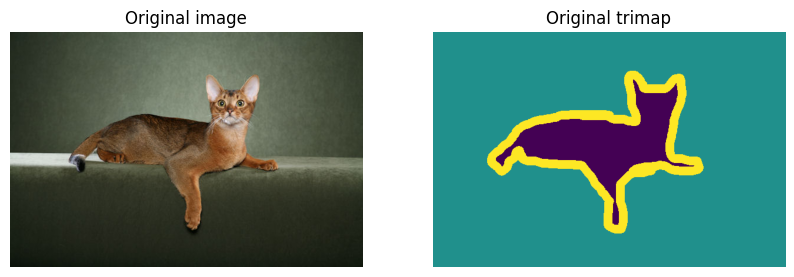

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Original trimap")
plt.axis("off")

plt.show()

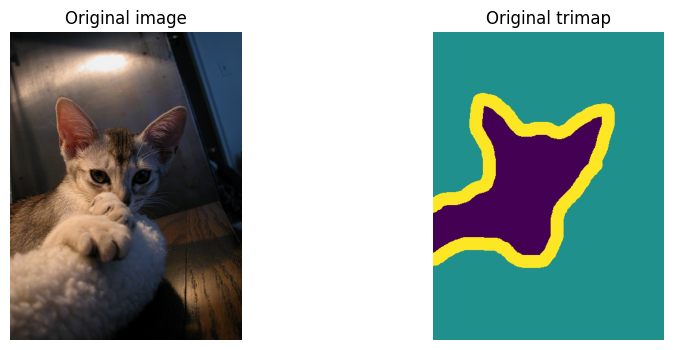

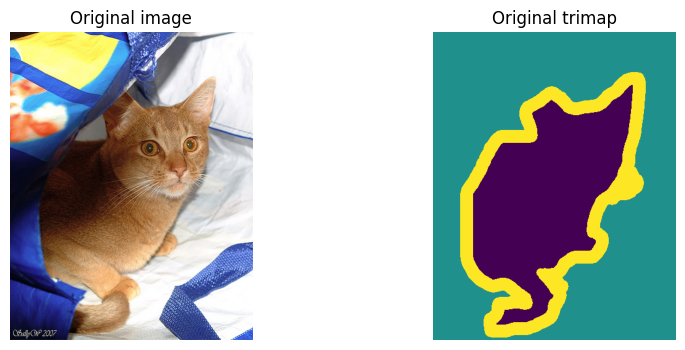

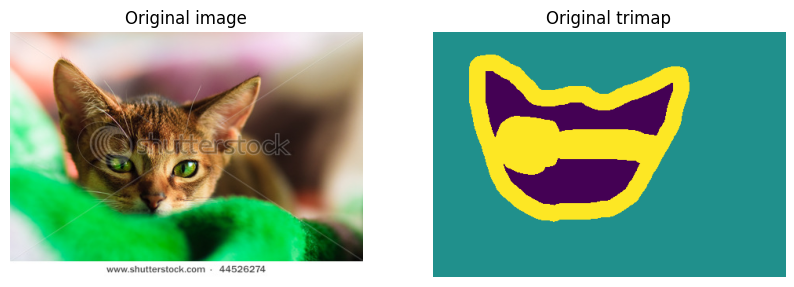

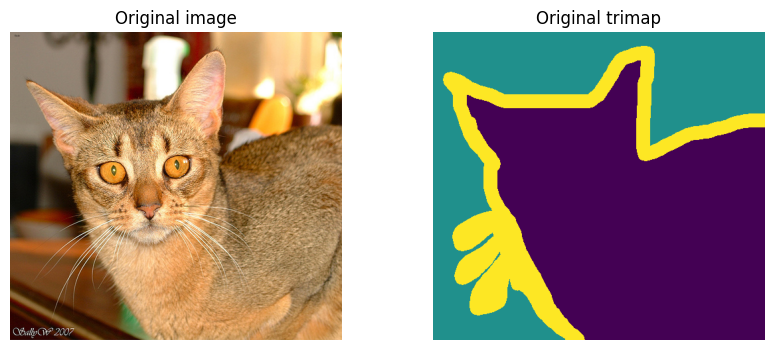

In [7]:
for i in range(1, 5):
    image, mask = dataset[i]

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask)
    plt.title("Original trimap")
    plt.axis("off")

    plt.show()

### 数据处理

#### 增强

In [8]:
transform = SegmentationTransform(  # 数据增强
    size=256
)

dataset = OxfordPetDataset(
    image_dir,
    mask_dir,
    transform=transform
) 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.0474076].


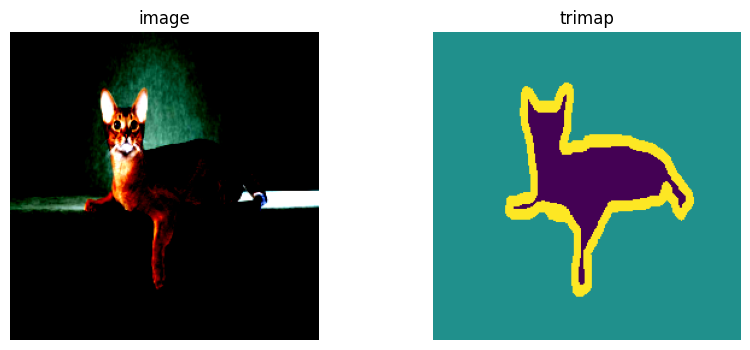

In [9]:
image, mask = dataset[0]

plt.figure(figsize=(10,4)) 

plt.subplot(1,2,1) 
plt.imshow( image.permute(1,2,0) ) 
plt.title("image") 
plt.axis("off") 

plt.subplot(1,2,2) 
plt.imshow( mask ) 
plt.title("trimap") 
plt.axis("off") 

plt.show()

In [10]:
print("数据数量:")
print(len(dataset))

image, mask = dataset[0]
print("----------------")
print("image shape:")
print(image.shape)

print("mask shape:")
print(mask.shape)

print("mask unique:")
print(mask.unique())

数据数量:
7390
----------------
image shape:
torch.Size([3, 256, 256])
mask shape:
torch.Size([256, 256])
mask unique:
tensor([0, 1, 2])


#### 创建DataLoader

In [11]:
dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

In [12]:
images, masks = next(iter(dataloader))

print("images:")
print(images.shape)

print("masks:")
print(masks.shape)

print("mask classes:")
print(masks.unique())

images:
torch.Size([8, 3, 256, 256])
masks:
torch.Size([8, 256, 256])
mask classes:
tensor([0, 1, 2])


In [13]:
def denormalize(img):

    mean = torch.tensor(
        [0.485,0.456,0.406]
    )

    std = torch.tensor(
        [0.229,0.224,0.225]
    )

    img = img.clone()


    for t,m,s in zip(
        img,
        mean,
        std
    ):
        t.mul_(s).add_(m)


    return img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.3088455].


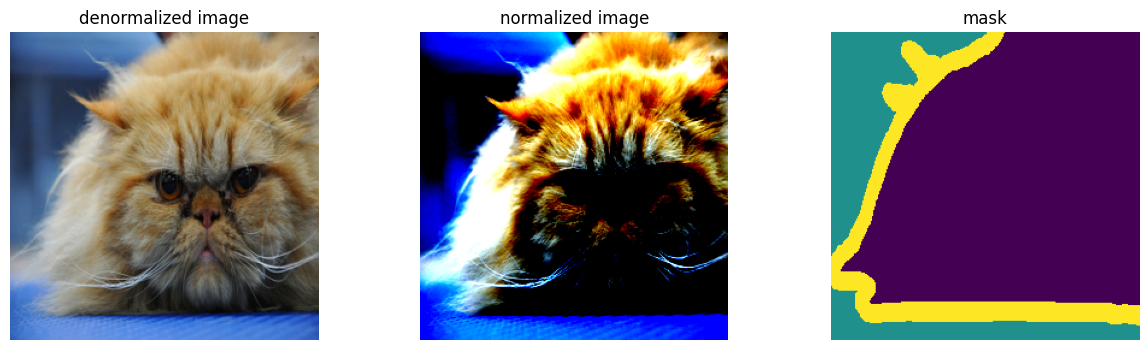

In [14]:
img = images[0]
mask = masks[0]
img_show = denormalize(images[0])

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img_show.permute(1,2,0))
plt.title("denormalized image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(
    img.permute(1,2,0)
)
plt.title("normalized image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask)
plt.title("mask")
plt.axis("off")

plt.show()

### 构建U-Net模型（Encoder + Decoder + Skip Connection）

#### U-Net核心层DoubleConv

In [15]:
class DoubleConv(nn.Module):

    """
    Basic convolution block

    Conv2d
    BatchNorm
    ReLU
    Conv2d
    BatchNorm
    ReLU
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                out_channels
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                out_channels
            ),
            nn.ReLU(inplace=True)

        )

    def forward(self,x):

        return self.conv(x)

#### Down采样模块

In [16]:
class Down(nn.Module):

    """
    Downsampling block

    MaxPool
    +
    DoubleConv
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(
                in_channels,
                out_channels
            )
        )

    def forward(self,x):

        return self.down(x)

#### Up采样模块

In [17]:
class Up(nn.Module):

    """
    Upsampling block

    Transposed convolution
    +
    skip connection
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels//2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(
        self,
        x1,
        x2
    ):

        # decoder feature
        x1=self.up(x1)

        # concat skip connection
        x=torch.cat(
            [x2,x1],
            dim=1
        )

        return self.conv(x)

#### U-Net主体

In [18]:
class UNet(nn.Module):

    """
    U-Net semantic segmentation model

    Input:
        RGB image

    Output:
        Pixel-wise class prediction
    """

    def __init__(
        self,
        num_classes=3
    ):

        super().__init__()

        self.inc = DoubleConv(
            3,
            32
        )
        self.down1 = Down(
            32,
            64
        )
        self.down2 = Down(
            64,
            128
        )

        self.down3 = Down(
            128,
            256
        )
        self.up1 = Up(
            256,
            128
        )
        self.up2 = Up(
            128,
            64
        )
        self.up3 = Up(
            64,
            32
        )

        self.out = nn.Conv2d(
            32,
            num_classes,
            1
        )


    def forward(self,x):

        x1=self.inc(x)
        x2=self.down1(x1)
        x3=self.down2(x2)
        x4=self.down3(x3)

        x=self.up1(
            x4,
            x3
        )
        x=self.up2(
            x,
            x2
        )
        x=self.up3(
            x,
            x1
        )

        output=self.out(x)

        return output

#### 测试

In [19]:
model=UNet(
    num_classes=3
).to(device)

x=torch.randn(
    2,
    3,
    256,
    256
).to(device)

y=model(x)
print(y.shape)

torch.Size([2, 3, 256, 256])


In [20]:
images, masks = next(iter(dataloader))
images = images.to(device)
masks = masks.to(device)

print(images.device)
print(masks.device)

print(next(model.parameters()).device)

cuda:0
cuda:0
cuda:0


### 模型训练

#### 初始化

In [21]:
# model
model = UNet(
    num_classes=3
)
model = model.to(device)

# loss
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

#### 训练函数

In [22]:
def pixel_accuracy(
    outputs,
    masks
):

    with torch.no_grad():

        preds = torch.argmax(
            outputs,
            dim=1
        )

        correct = (
            preds == masks
        ).sum()

        total = masks.numel()

        acc = (
            correct.float()
            /
            total
        )

    return acc.item()

In [23]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0
    total_acc = 0


    for images,masks in loader:

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        acc = pixel_accuracy(
            outputs,
            masks
        )


        total_loss += loss.item()

        total_acc += acc



    return (
        total_loss / len(loader),
        total_acc / len(loader)
    )

#### 验证函数

In [24]:
def validate(
    model,
    loader,
    criterion,
    device
):

    """
    Validation

    Return:
        avg_loss
        avg_accuracy
    """

    model.eval()
    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad():


        for images, masks in loader:

            images = images.to(
                device,
                non_blocking=True
            )
            masks = masks.to(
                device,
                non_blocking=True
            )

            outputs = model(images)
            loss = criterion(
                outputs,
                masks
            )

            acc = pixel_accuracy(
                outputs,
                masks
            )

            running_loss += loss.item()
            running_acc += acc

    epoch_loss = (
        running_loss /
        len(loader)
    )
    epoch_acc = (
        running_acc /
        len(loader)
    )

    return epoch_loss, epoch_acc

#### 训练

In [25]:
train_size = int(
    0.8 * len(dataset)
)
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

In [26]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [27]:
# best_loss = float("inf")

train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 10
for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
        # scaler
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"""
        Epoch [{epoch+1}/{epochs}]
        Train | Loss:{train_loss:.4f} Acc:{train_acc:.4f} Validation | Loss:{val_loss:.4f} Acc:{val_acc:.4f}
        """
    )

    # # 保存最佳模型
    # if val_loss < best_loss:

    #     best_loss = val_loss
    #     torch.save(
    #         model.state_dict(),
    #         "best_unet.pth"
    #     )
    #     print(
    #         "Saved best model!"
    #     )


    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)


        Epoch [1/10]
        Train | Loss:0.6585 Acc:0.7250 Validation | Loss:0.5398 Acc:0.7816
        

        Epoch [2/10]
        Train | Loss:0.5034 Acc:0.7999 Validation | Loss:0.5082 Acc:0.7985
        

        Epoch [3/10]
        Train | Loss:0.4442 Acc:0.8254 Validation | Loss:0.4283 Acc:0.8330
        

        Epoch [4/10]
        Train | Loss:0.4079 Acc:0.8412 Validation | Loss:0.3847 Acc:0.8489
        

        Epoch [5/10]
        Train | Loss:0.3774 Acc:0.8534 Validation | Loss:0.3660 Acc:0.8569
        

        Epoch [6/10]
        Train | Loss:0.3573 Acc:0.8617 Validation | Loss:0.3390 Acc:0.8697
        

        Epoch [7/10]
        Train | Loss:0.3453 Acc:0.8666 Validation | Loss:0.3421 Acc:0.8689
        

        Epoch [8/10]
        Train | Loss:0.3258 Acc:0.8747 Validation | Loss:0.3206 Acc:0.8769
        

        Epoch [9/10]
        Train | Loss:0.3167 Acc:0.8778 Validation | Loss:0.3187 Acc:0.8774
        

        Epoch [10/10]
        Train | Loss:0.

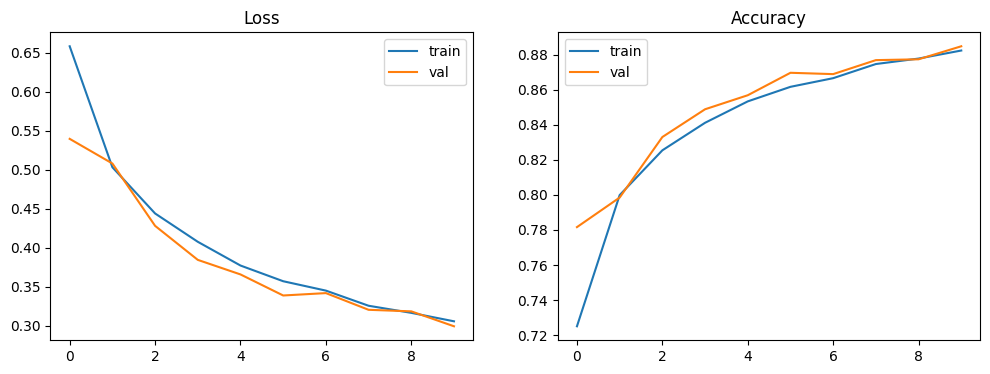

In [28]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(
    train_losses,
    label="train"
)
plt.plot(
    val_losses,
    label="val"
)
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(
    train_accs,
    label="train"
)
plt.plot(
    val_accs,
    label="val"
)
plt.title("Accuracy")
plt.legend()

plt.show()

### 推理

In [29]:
model.eval()

UNet(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (down): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [30]:
image, mask = val_dataset[0]

# 保存真实尺寸
input_image = image.unsqueeze(0).to(device)
with torch.no_grad():
    output = model(
        input_image
    )

# 分类结果
pred = torch.argmax(
    output,
    dim=1
)
pred = pred.squeeze(0).cpu().numpy()

print(
    "Prediction shape:",
    pred.shape
)
print(
    "Prediction classes:",
    np.unique(pred)
)

Prediction shape: (256, 256)
Prediction classes: [0 1 2]


In [31]:
img_show = denormalize(
    image.cpu()
)
img_show = img_show.permute(
    1,2,0
)

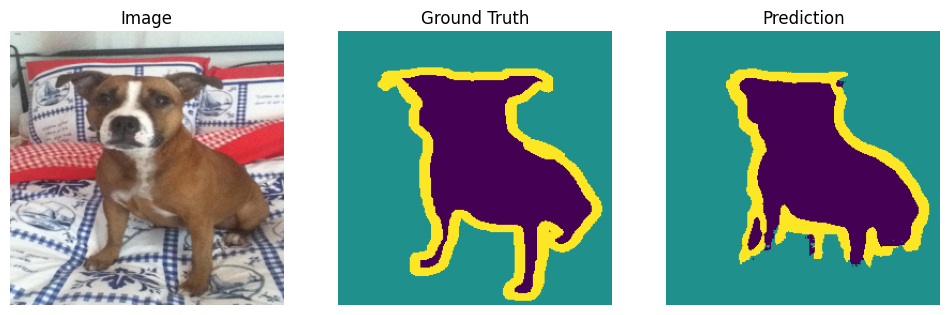

In [32]:
plt.figure(figsize=(12,4))

# 原图
plt.subplot(1,3,1)
plt.imshow(
    img_show
)
plt.title(
    "Image"
)
plt.axis("off")

# 真实标签
plt.subplot(1,3,2)
plt.imshow(
    mask
)
plt.title(
    "Ground Truth"
)
plt.axis("off")


# 预测结果
plt.subplot(1,3,3)
plt.imshow(
    pred
)
plt.title(
    "Prediction"
)
plt.axis("off")

plt.show()